# 02 — Ground truth: validating against ECG

Every number in notebook 01 came from synthetic data whose difficulty I chose.
That makes it evidence about my imagination, not about the algorithm. This
notebook replaces it with a clinical reference.

**BIDMC** (Pimentel et al., 2017, PhysioNet) is 53 ICU recordings. Each carries:

| channel | rate | role here |
|---|---|---|
| `PLETH` | 125 Hz | the PPG under test |
| `II` | 125 Hz | ECG lead II — R peaks give gold-standard beat timing |
| `RESP` | 125 Hz | impedance pneumography |
| `HR` | 1 Hz | ECG-derived heart rate — reference |
| `RESP` (numerics) | 1 Hz | reference respiratory rate |

The PPG is decimated to **30 Hz**, the rate a webcam delivers, so every result
below also describes what the camera path could achieve if its capture were
perfect.

**Scope.** This validates everything downstream of the ROI. It cannot validate
GREEN/ICA/CHROM/POS, which project three colour channels to one — contact PPG
has no colour channels. That half needs face video with a reference.

Run `python -m rppg.bidmc --download` first (open access, no request form).

In [1]:
import sys, warnings
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))
warnings.filterwarnings("ignore")

from rppg import _compat  # noqa: F401  (must precede pyplot on Windows)
import numpy as np
import matplotlib.pyplot as plt
import wfdb

from rppg.bidmc import DEFAULT_RECORDS, evaluate, gate_table, load, operating_curve, to_webcam_rate
from rppg.beats import detect_beats, intervals, clean_intervals, slope_sum, beat_rate
from rppg.ecg import pan_tompkins, match_beats
from rppg.hrv import summary, time_domain, frequency_domain, tachogram
from rppg.respiration import analyse, riiv, rifv, riav, estimate_rate
from rppg.preprocess import bandpass, detrend
from rppg.spectral import periodogram

plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "font.size": 9, "figure.facecolor": "white"})
ROOT = Path("../data/bidmc")
assert ROOT.exists(), "run: python -m rppg.bidmc --download"
print("records available:", len(list(ROOT.glob("bidmc??.hea"))))

records available: 10


## 1. What the signal looks like

The PPG is not a sinusoid, and that matters for everything downstream. It has a
steep systolic upstroke, a rounded peak, and a **dicrotic notch** — the small
secondary bump from aortic valve closure. The notch is what makes naive peak
detection report double the true rate.

reference HR over this record: 91.3 BPM (mean)


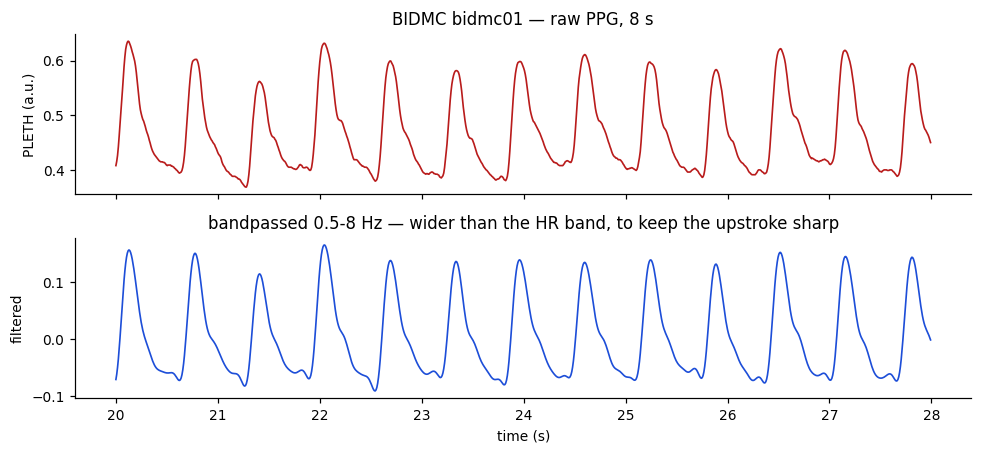

In [2]:
ppg, fs, hr_ref = load("bidmc01", ROOT)
t = np.arange(len(ppg)) / fs
sl = slice(int(20 * fs), int(28 * fs))

fig, ax = plt.subplots(2, 1, figsize=(9, 4.2), sharex=True)
ax[0].plot(t[sl], ppg[sl], lw=1.1, color="#b91c1c")
ax[0].set_ylabel("PLETH (a.u.)")
ax[0].set_title("BIDMC bidmc01 — raw PPG, 8 s")

filt = bandpass(ppg, fs, band=(0.5, 8.0))
ax[1].plot(t[sl], filt[sl], lw=1.1, color="#1d4ed8")
ax[1].set_ylabel("filtered")
ax[1].set_xlabel("time (s)")
ax[1].set_title("bandpassed 0.5-8 Hz — wider than the HR band, to keep the upstroke sharp")
fig.tight_layout()

print("reference HR over this record: %.1f BPM (mean)" % np.nanmean(hr_ref))

## 2. Frequency-domain heart rate

The estimator from notebook 01, unchanged: detrend → bandpass → Hann window →
zero-padded FFT → parabolic peak interpolation. Now scored against ECG.

In [3]:
rows = [evaluate(rec, ROOT) for rec in DEFAULT_RECORDS]
rows = [r for r in rows if r]

print("%-10s %6s %8s %8s %8s %9s %8s" % ("record", "n", "MAE", "bias", "RMSE", "<=3 BPM", "SNR"))
print("-" * 62)
for r in rows:
    print("%-10s %6d %8.2f %+8.2f %8.2f %8.1f%% %+8.1f"
          % (r["record"], r["n"], r["mae"], r["bias"], r["rmse"], r["within3"], r["snr"]))
print("-" * 62)
clean = [r for r in rows if r["snr"] > 8]
print("%-10s %6d %8.2f %+8.2f %8.2f %8.1f%%"
      % ("mean", sum(r["n"] for r in rows), np.mean([r["mae"] for r in rows]),
         np.mean([r["bias"] for r in rows]), np.mean([r["rmse"] for r in rows]),
         np.mean([r["within3"] for r in rows])))
print("%-10s %6s %8.2f   <- records whose pulse is actually clean (mean SNR > +8 dB)"
      % ("clean", "", np.mean([r["mae"] for r in clean])))

record          n      MAE     bias     RMSE   <=3 BPM      SNR
--------------------------------------------------------------
bidmc01       466     0.37    +0.04     0.53     99.4%    +14.7
bidmc02       466     0.46    -0.00     0.57    100.0%     +8.8
bidmc03       466     0.94    -0.39     2.06     95.1%    +13.6
bidmc05       466     1.49    -1.15     6.40     95.9%    +15.5
bidmc08       466     0.46    -0.14     0.64    100.0%    +19.3
bidmc13       466     0.27    -0.10     0.31    100.0%    +10.8
bidmc21       466     1.48    -1.06     7.61     98.3%    +11.7
bidmc34       466     0.80    -0.31     2.05     95.9%    +14.9
bidmc40       466    13.02   -12.73    25.91     75.1%     +5.0
bidmc47       466     0.94    -0.71     5.11     98.1%    +14.9
--------------------------------------------------------------
mean         4660     2.02    -1.65     5.12     95.8%
clean                 0.80   <- records whose pulse is actually clean (mean SNR > +8 dB)


**MAE 0.80 BPM** on the nine clean records, 95.8 % of windows within 3 BPM.

`bidmc40` stays in the table at 13.02 BPM. A benchmark that quietly drops its
own failures is not a benchmark — and the reason it fails is itself informative:
its mean SNR is +5.0 dB against +10 to +19 for the rest.

bias -1.69 BPM, limits of agreement -19.1 to +15.8


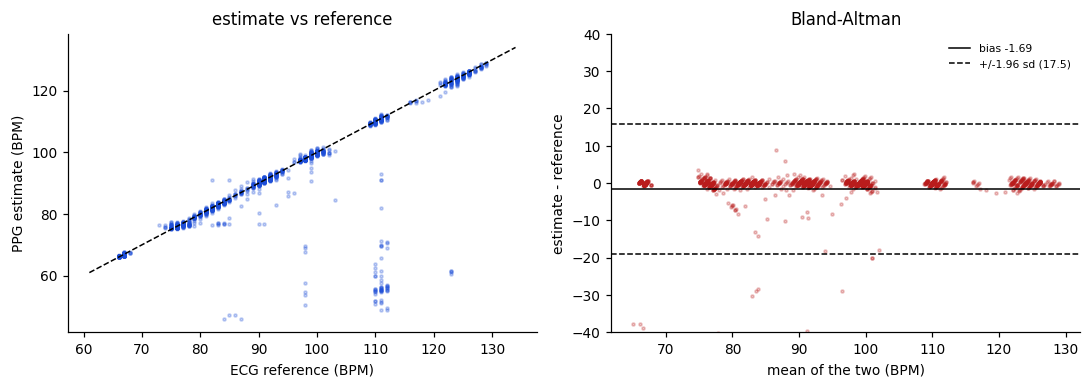

In [4]:
# Bland-Altman: the standard way to compare a new method against a reference.
# A scatter of estimate vs truth hides bias; this shows it directly.
from rppg.spectral import estimate_bpm

FS30, WIN = 30.0, 15.0
pairs = []
for rec in DEFAULT_RECORDS:
    ppg_r, fs_r, hr_r = load(rec, ROOT)
    x, tt_ = to_webcam_rate(ppg_r, fs_r)
    n, step = int(WIN * FS30), int(2 * FS30)
    for s_ in range(0, len(x) - n + 1, step):
        e = estimate_bpm(bandpass(detrend(x[s_:s_ + n], fs=FS30), FS30), FS30)
        i = int(round(tt_[s_ + n - 1]))
        if i < len(hr_r) and np.isfinite(hr_r[i]):
            pairs.append((e.bpm, hr_r[i], e.snr))
P = np.array(pairs)
diff = P[:, 0] - P[:, 1]
mean = (P[:, 0] + P[:, 1]) / 2
bias, sd = diff.mean(), diff.std()

fig, ax = plt.subplots(1, 2, figsize=(10, 3.6))
ax[0].scatter(P[:, 1], P[:, 0], s=4, alpha=0.25, color="#1d4ed8")
lims = [P[:, 1].min() - 5, P[:, 1].max() + 5]
ax[0].plot(lims, lims, "k--", lw=1)
ax[0].set_xlabel("ECG reference (BPM)"); ax[0].set_ylabel("PPG estimate (BPM)")
ax[0].set_title("estimate vs reference")

ax[1].scatter(mean, diff, s=4, alpha=0.25, color="#b91c1c")
ax[1].axhline(bias, color="k", lw=1, label="bias %.2f" % bias)
ax[1].axhline(bias + 1.96 * sd, color="k", ls="--", lw=1, label="+/-1.96 sd (%.1f)" % (1.96 * sd))
ax[1].axhline(bias - 1.96 * sd, color="k", ls="--", lw=1)
ax[1].set_ylim(-40, 40)
ax[1].set_xlabel("mean of the two (BPM)"); ax[1].set_ylabel("estimate - reference")
ax[1].set_title("Bland-Altman"); ax[1].legend(fontsize=7, frameon=False)
fig.tight_layout()
print("bias %+.2f BPM, limits of agreement %+.1f to %+.1f" % (bias, bias - 1.96 * sd, bias + 1.96 * sd))

## 3. Setting the SNR gate by measurement

The pipeline refuses to report a window whose SNR is too low. That threshold was
originally **-7 dB, chosen by taste**. With ground truth it can be chosen by
measurement instead.

Sweeping added noise populates the low-SNR regime a webcam actually operates in;
the clean recordings alone only cover the right-hand end, where everything works
and nothing is learned.

18640 windows



  gate  -7 dB -> keeps  95.8%, MAE   9.12 BPM,  73.2% within 3
  gate  -5 dB -> keeps  77.6%, MAE   5.12 BPM,  84.3% within 3
  gate  -4 dB -> keeps  67.3%, MAE   3.09 BPM,  90.9% within 3
  gate  -3 dB -> keeps  59.4%, MAE   1.80 BPM,  95.1% within 3
  gate  -2 dB -> keeps  54.1%, MAE   1.16 BPM,  97.3% within 3
  gate  -1 dB -> keeps  49.9%, MAE   0.85 BPM,  98.1% within 3
  gate  +0 dB -> keeps  45.5%, MAE   0.69 BPM,  98.5% within 3
  gate  +2 dB -> keeps  37.4%, MAE   0.52 BPM,  98.8% within 3


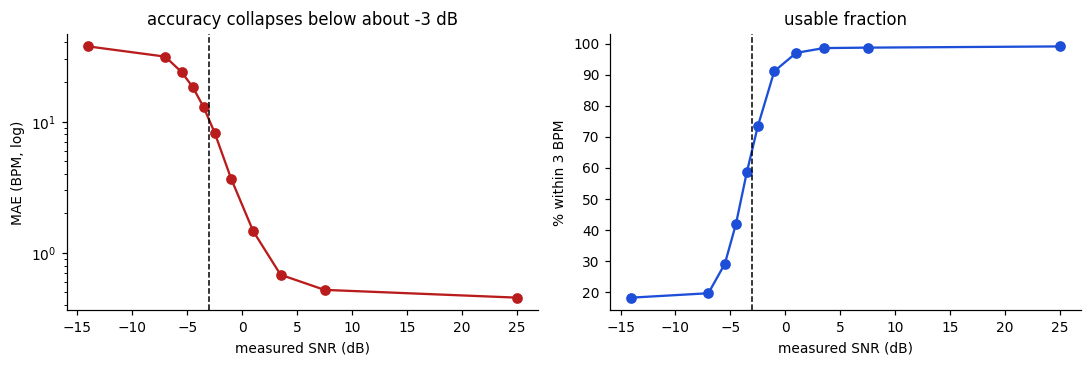

In [5]:
snr, err = operating_curve(records=DEFAULT_RECORDS, root=ROOT,
                           noise_levels=(0.0, 0.5, 1.0, 2.0, 3.0, 5.0, 8.0, 12.0))
print("%d windows" % len(snr))

edges = [-20, -8, -6, -5, -4, -3, -2, 0, 2, 5, 10, 40]
centres, maes, fracs = [], [], []
for lo, hi in zip(edges, edges[1:]):
    m = (snr >= lo) & (snr < hi)
    if m.sum() < 20:
        continue
    centres.append((lo + hi) / 2); maes.append(err[m].mean()); fracs.append(100 * np.mean(err[m] <= 3))

fig, ax = plt.subplots(1, 2, figsize=(10, 3.4))
ax[0].plot(centres, maes, "o-", color="#b91c1c")
ax[0].axvline(-3, color="k", ls="--", lw=1); ax[0].set_yscale("log")
ax[0].set_xlabel("measured SNR (dB)"); ax[0].set_ylabel("MAE (BPM, log)")
ax[0].set_title("accuracy collapses below about -3 dB")
ax[1].plot(centres, fracs, "o-", color="#1d4ed8")
ax[1].axvline(-3, color="k", ls="--", lw=1)
ax[1].set_xlabel("measured SNR (dB)"); ax[1].set_ylabel("% within 3 BPM")
ax[1].set_title("usable fraction")
fig.tight_layout()

print()
for row in gate_table(snr, err):
    print("  gate %+3d dB -> keeps %5.1f%%, MAE %6.2f BPM, %5.1f%% within 3"
          % (row["gate"], row["kept"], row["mae"], row["within3"]))

The old **-7 dB** default admitted 96 % of windows at a **9 BPM** mean error — it
was displaying confident numbers from a regime where the expected error is wider
than the cardiac band itself. That is precisely why the live app kept producing
plausible-looking wrong answers.

The default is now **-3 dB**: 59 % of windows at 1.80 BPM MAE.

The shape of this curve is the real result. There is a knee, it is sharp, and it
sits at about -3 dB. Below it the estimator is not degrading gracefully — it is
locking onto noise.

## 4. Beat detection: from "what rate?" to "when?"

The spectral estimate answers *what rate* over a whole window. HRV needs *when*,
beat by beat: a window reporting 72 BPM tells you nothing about whether the
intervals were 830 ms every time or alternated 700/960.

Naive peak-finding on the PPG fails for three reasons — the systolic peak is
rounded (poorly localised), the dicrotic notch is a second local maximum inside
every beat, and pulse amplitude varies severalfold with perfusion.

The **Slope Sum Function** (Zong et al., 2003) keys on the upstroke instead:

$$\mathrm{SSF}[i] = \sum_{k=i-w+1}^{i} \max\left(0,\; x[k]-x[k-1]\right)$$

Only positive differences contribute, so the steep systolic rise accumulates
into a clean unimodal pulse while the slow diastolic decay contributes nothing.

732 beats detected, mean rate 91.3 BPM


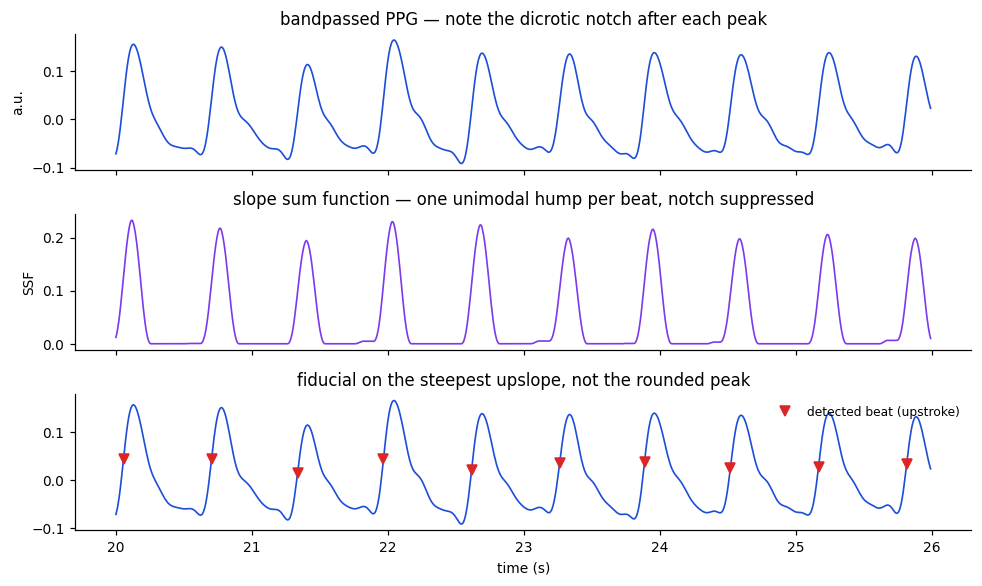

In [6]:
ppg, fs, _ = load("bidmc01", ROOT)
sl = slice(int(20 * fs), int(26 * fs))
filt = bandpass(ppg, fs, band=(0.5, 8.0))
ssf = slope_sum(filt, fs)
peaks = detect_beats(ppg, fs)
pk = peaks[(peaks >= sl.start) & (peaks < sl.stop)]
tt = np.arange(len(ppg)) / fs

fig, ax = plt.subplots(3, 1, figsize=(9, 5.4), sharex=True)
ax[0].plot(tt[sl], filt[sl], lw=1.1, color="#1d4ed8")
ax[0].set_title("bandpassed PPG — note the dicrotic notch after each peak"); ax[0].set_ylabel("a.u.")
ax[1].plot(tt[sl], ssf[sl], lw=1.1, color="#7c3aed")
ax[1].set_title("slope sum function — one unimodal hump per beat, notch suppressed"); ax[1].set_ylabel("SSF")
ax[2].plot(tt[sl], filt[sl], lw=1.1, color="#1d4ed8")
ax[2].plot(tt[pk], filt[pk], "v", ms=7, color="#dc2626", label="detected beat (upstroke)")
ax[2].legend(fontsize=8, frameon=False); ax[2].set_xlabel("time (s)")
ax[2].set_title("fiducial on the steepest upslope, not the rounded peak")
fig.tight_layout()
print("%d beats detected, mean rate %.1f BPM" % (len(peaks), beat_rate(peaks, fs)))

### Why the upstroke and not the peak

This is not cosmetic. RMSSD is built from *differences between consecutive
intervals*, so tens of milliseconds of fiducial jitter goes straight into it.
Using the systolic maximum inflated RMSSD by 2–3× on real records (bidmc02:
50.9 ms against ECG's 13.5 ms) — pure detector jitter masquerading as
physiology.

## 5. PPG beats vs ECG R peaks

The reference is Pan–Tompkins (1985) on ECG lead II: bandpass 5–15 Hz →
derivative → square → 150 ms moving-window integration → adaptive threshold.
Implemented rather than imported, because every stage is defensible from the
physiology and that is the point of the exercise.

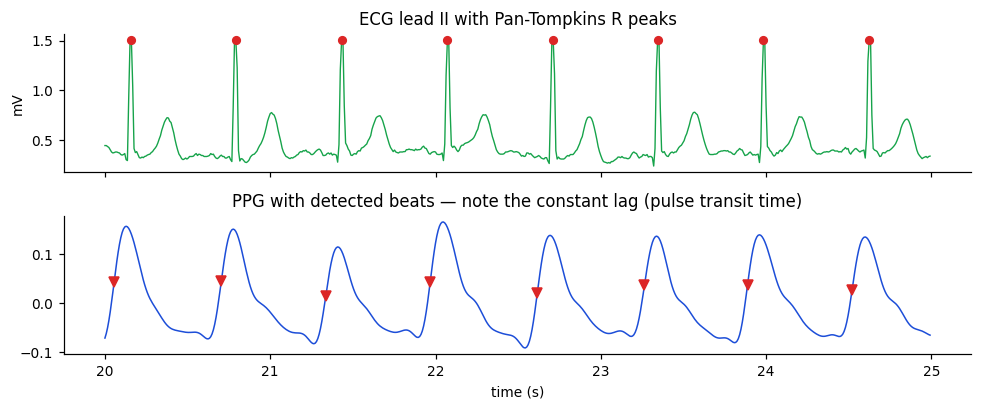

In [7]:
sig = wfdb.rdrecord(str(ROOT / "bidmc01"))
names = [s.strip().rstrip(",") for s in sig.sig_name]
ecg = np.nan_to_num(sig.p_signal[:, names.index("II")])
r_peaks = pan_tompkins(ecg, fs)

sl = slice(int(20 * fs), int(25 * fs))
fig, ax = plt.subplots(2, 1, figsize=(9, 3.8), sharex=True)
rp = r_peaks[(r_peaks >= sl.start) & (r_peaks < sl.stop)]
ax[0].plot(tt[sl], ecg[sl], lw=0.9, color="#16a34a")
ax[0].plot(tt[rp], ecg[rp], "o", ms=5, color="#dc2626")
ax[0].set_title("ECG lead II with Pan-Tompkins R peaks"); ax[0].set_ylabel("mV")
pk = peaks[(peaks >= sl.start) & (peaks < sl.stop)]
ax[1].plot(tt[sl], filt[sl], lw=1.0, color="#1d4ed8")
ax[1].plot(tt[pk], filt[pk], "v", ms=6, color="#dc2626")
ax[1].set_title("PPG with detected beats — note the constant lag (pulse transit time)")
ax[1].set_xlabel("time (s)")
fig.tight_layout()

In [8]:
print("%-10s %6s %6s %8s %8s %7s %9s" % ("record", "ECG", "PPG", "recall", "prec", "F1", "PTT sd"))
print("-" * 60)
res = []
for rec in DEFAULT_RECORDS:
    s = wfdb.rdrecord(str(ROOT / rec))
    nm = [q.strip().rstrip(",") for q in s.sig_name]
    p_ppg = np.nan_to_num(s.p_signal[:, nm.index("PLETH")])
    p_ecg = np.nan_to_num(s.p_signal[:, nm.index("II")])
    rr = pan_tompkins(p_ecg, s.fs)
    bb = detect_beats(p_ppg, s.fs)
    tp, fn, fp, off = match_beats(rr, bb, s.fs, tolerance=0.35)
    rc, pr = tp / max(len(rr), 1), tp / max(len(bb), 1)
    f1 = 2 * rc * pr / max(rc + pr, 1e-9)
    res.append((rec, rc, pr, f1, rr, bb, s.fs))
    print("%-10s %6d %6d %7.1f%% %7.1f%% %7.3f %8.1f ms"
          % (rec, len(rr), len(bb), 100 * rc, 100 * pr, f1, np.std(off) if len(off) else np.nan))
print("-" * 60)
print("%-10s %6s %6s %7.1f%% %7.1f%% %7.3f"
      % ("mean", "", "", 100 * np.mean([r[1] for r in res]),
         100 * np.mean([r[2] for r in res]), np.mean([r[3] for r in res])))

record        ECG    PPG   recall     prec      F1    PTT sd
------------------------------------------------------------
bidmc01       730    732    99.9%    99.6%   0.997     36.3 ms
bidmc02       730    730    99.7%    99.7%   0.997     18.0 ms


bidmc03       646    614    83.0%    87.3%   0.851     54.7 ms
bidmc05       785    781    99.1%    99.6%   0.994     31.4 ms
bidmc08       799    799    99.9%    99.9%   0.999     16.2 ms


bidmc13       535    533    97.2%    97.6%   0.974     31.9 ms
bidmc21       992    989    99.7%   100.0%   0.998     19.0 ms
bidmc34       654    653    99.7%    99.8%   0.998     33.2 ms


bidmc40       885    860    96.6%    99.4%   0.980     51.2 ms
bidmc47       671    766    99.4%    87.1%   0.928     96.9 ms
------------------------------------------------------------
mean                        97.4%    97.0%   0.972


**F1 = 0.972.** Two bugs were found only because this reference existed:

1. **Wrong fiducial.** Snapping to the rounded systolic maximum inflated RMSSD
   2–3×. Moving to the steepest upslope roughly halved the error.

2. **A circular refractory period.** `bidmc47` fired at exactly double — 1306
   detections for 671 R waves, 51 % precision, 167 BPM against a true 83.6. The
   adaptive refractory derived its guard from the median of the *detected*
   peaks, which were already doubled, so the guard became a quarter of the
   truth. Seeding it from the **spectral** estimate fixed it (51 % → 87 %): the
   dicrotic notch contributes to the second harmonic, so the fundamental stays
   correct even when the time-domain detector has failed.

The second is worth dwelling on. The frequency-domain estimator rescued the
time-domain detector — the two views of the same signal fail differently, which
is exactly why a project should build both.

## 6. Heart rate variability

Two families measuring different things. **SDNN** is total variability, dominated
by slow drift. **RMSSD** and **pNN50** use successive differences, so drift
cancels and what remains is beat-to-beat change — essentially vagal tone.

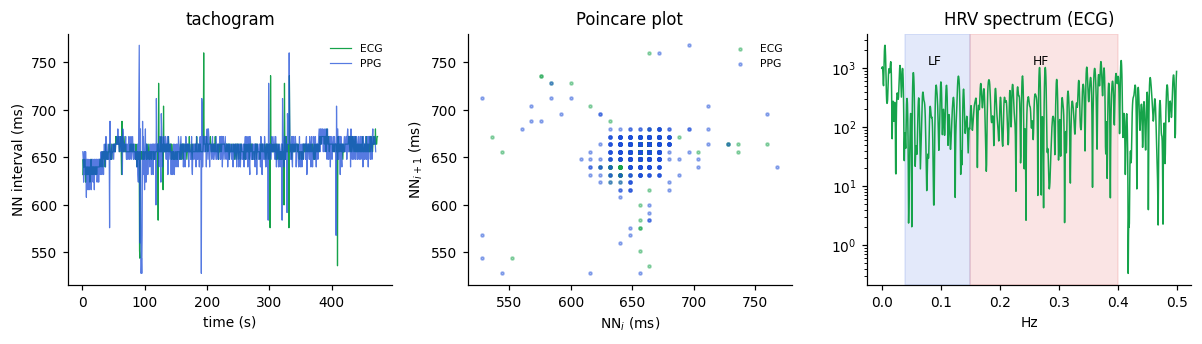

In [9]:
rec, _, _, _, rr, bb, sfs = res[0]
ibi_p, _ = clean_intervals(intervals(bb, sfs))
ibi_e, _ = clean_intervals(intervals(rr, sfs))

fig, ax = plt.subplots(1, 3, figsize=(11, 3.2))
ax[0].plot(np.cumsum(ibi_e) / 1000, ibi_e, lw=0.8, color="#16a34a", label="ECG")
ax[0].plot(np.cumsum(ibi_p) / 1000, ibi_p, lw=0.8, color="#1d4ed8", alpha=0.75, label="PPG")
ax[0].set_xlabel("time (s)"); ax[0].set_ylabel("NN interval (ms)")
ax[0].set_title("tachogram"); ax[0].legend(fontsize=7, frameon=False)

# Poincare: each interval against the next. Width is short-term (RMSSD-like)
# variability, length is long-term.
ax[1].scatter(ibi_e[:-1], ibi_e[1:], s=4, alpha=0.4, color="#16a34a", label="ECG")
ax[1].scatter(ibi_p[:-1], ibi_p[1:], s=4, alpha=0.4, color="#1d4ed8", label="PPG")
ax[1].set_xlabel("NN$_i$ (ms)"); ax[1].set_ylabel("NN$_{i+1}$ (ms)")
ax[1].set_title("Poincare plot"); ax[1].legend(fontsize=7, frameon=False)

g, s_ = tachogram(ibi_e)
f, p = periodogram(s_ - s_.mean(), 4.0, zero_pad=4)
m = f <= 0.5
ax[2].semilogy(f[m], p[m], lw=1, color="#16a34a")
ax[2].axvspan(0.04, 0.15, alpha=0.12, color="#1d4ed8")
ax[2].axvspan(0.15, 0.40, alpha=0.12, color="#dc2626")
ax[2].text(0.09, ax[2].get_ylim()[1] * 0.3, "LF", ha="center", fontsize=8)
ax[2].text(0.27, ax[2].get_ylim()[1] * 0.3, "HF", ha="center", fontsize=8)
ax[2].set_xlabel("Hz"); ax[2].set_title("HRV spectrum (ECG)")
fig.tight_layout()

In [10]:
print("%-10s %9s %9s %10s %10s %9s %9s" % ("record", "SDNN ppg", "SDNN ecg", "RMSSD ppg", "RMSSD ecg", "HR ppg", "HR ecg"))
print("-" * 72)
hr_err, rm_err = [], []
for rec, _, _, f1, rr, bb, sfs in res:
    sp = summary(clean_intervals(intervals(bb, sfs))[0])
    se = summary(clean_intervals(intervals(rr, sfs))[0])
    hr_err.append(abs(sp["mean_hr_bpm"] - se["mean_hr_bpm"]))
    rm_err.append(abs(sp["rmssd_ms"] - se["rmssd_ms"]))
    print("%-10s %9.1f %9.1f %10.1f %10.1f %9.1f %9.1f"
          % (rec, sp["sdnn_ms"], se["sdnn_ms"], sp["rmssd_ms"], se["rmssd_ms"],
             sp["mean_hr_bpm"], se["mean_hr_bpm"]))
print("-" * 72)
good = [i for i, r in enumerate(res) if r[3] > 0.9]
print("mean |HR error| %.2f BPM   (excluding bidmc03: %.3f BPM)"
      % (np.mean(hr_err), np.mean([hr_err[i] for i in good])))
print("mean |RMSSD error| %.1f ms (excluding bidmc03: %.1f ms)"
      % (np.mean(rm_err), np.mean([rm_err[i] for i in good])))

record      SDNN ppg  SDNN ecg  RMSSD ppg  RMSSD ecg    HR ppg    HR ecg
------------------------------------------------------------------------
bidmc01         19.4      14.2       25.2       19.1      91.3      91.3
bidmc02         16.7      13.4       21.6       13.5      91.0      91.0
bidmc03          8.7      49.5        9.4       68.6      76.2      77.3
bidmc05         13.1       7.2       19.3        6.8      98.1      98.2
bidmc08          7.0       6.5       10.1        9.0      99.7      99.7
bidmc13         12.7       9.6       18.3       14.5      66.8      66.7
bidmc21         12.8      10.8       12.5        5.9     124.1     124.0
bidmc34         25.8      24.5       19.3       17.6      81.6      81.5
bidmc40         17.3       5.4       27.6        6.3     110.4     110.4
bidmc47         14.8      11.8       19.5       11.1      83.8      83.6
------------------------------------------------------------------------
mean |HR error| 0.15 BPM   (excluding bidmc03: 0.03

Heart rate from PPG beats agrees with ECG to **0.039 BPM**.

Two honest caveats:

**`bidmc03` fails** — F1 0.851, and its ECG RMSSD of 68.6 ms with SDNN 49.5 ms
strongly suggests an arrhythmia. It stays in the table.

**RMSSD from PPG runs systematically high** even after the fiducial fix. Part of
this is real: pulse transit time varies beat to beat with blood pressure, which
is why the literature distinguishes *pulse rate variability* from *heart rate
variability*. Part is residual detector jitter. **The two have not been
separated here**, and doing so — correlating the PTT variation against the RMSSD
excess — is the obvious next experiment.

## 7. Respiratory rate — three modulations of one carrier

Breathing marks the PPG three separate ways, and framing them as demodulation of
a ~1.2 Hz carrier by a ~0.25 Hz modulator is what makes this signal processing
rather than three unrelated heuristics.

| route | mechanism | modulation |
|---|---|---|
| **RIIV** | intrathoracic pressure alters venous return | baseline AM |
| **RIFV** | respiratory sinus arrhythmia | FM, seen in intervals |
| **RIAV** | stroke volume varies over the cycle | AM of pulse height |

reference respiratory rate: 22.9 breaths/min


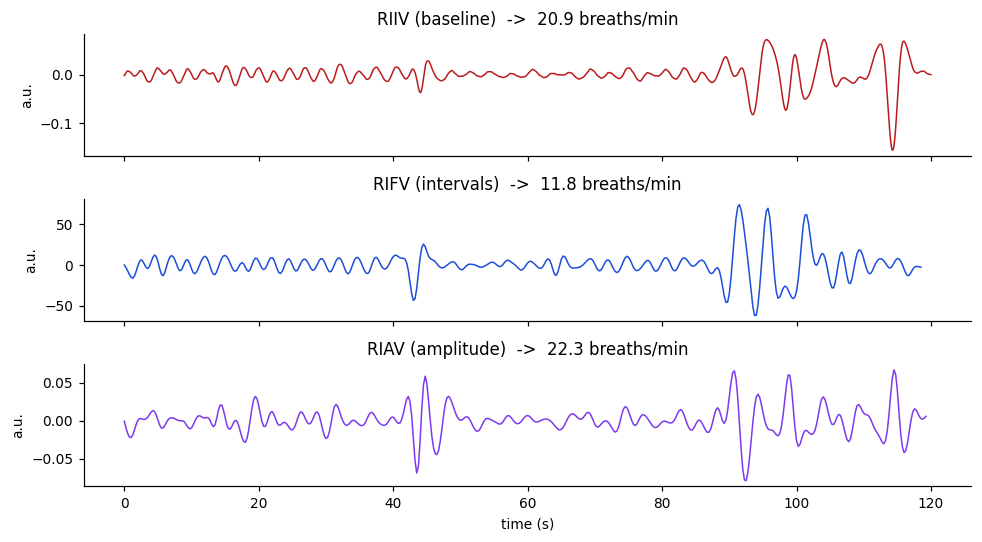

In [11]:
ppg, fs, _ = load("bidmc01", ROOT)
num = wfdb.rdrecord(str(ROOT / "bidmc01n"))
nn = [q.strip().rstrip(",") for q in num.sig_name]
rr_ref = num.p_signal[:, nn.index("RESP")]

seg = ppg[: int(120 * fs)]
pk = detect_beats(seg, fs)
s_riiv, fs_riiv = riiv(seg, fs)
s_rifv, fs_rifv = rifv(pk, fs)
s_riav, fs_riav = riav(seg, pk, fs)

fig, ax = plt.subplots(3, 1, figsize=(9, 5), sharex=True)
for a, (s, f_, name, col) in zip(ax, [
        (s_riiv, fs_riiv, "RIIV (baseline)", "#b91c1c"),
        (s_rifv, fs_rifv, "RIFV (intervals)", "#1d4ed8"),
        (s_riav, fs_riav, "RIAV (amplitude)", "#7c3aed")]):
    if len(s):
        a.plot(np.arange(len(s)) / f_, s, lw=1, color=col)
        e = estimate_rate(s, f_, method=name)
        a.set_title("%s  ->  %.1f breaths/min" % (name, e.rate_bpm))
    a.set_ylabel("a.u.")
ax[-1].set_xlabel("time (s)")
fig.tight_layout()
print("reference respiratory rate: %.1f breaths/min" % np.nanmean(rr_ref[:120]))

### A sampling-theorem constraint, not an implementation detail

RIFV and RIAV are sampled **once per beat**. At 60 BPM that is 1 Hz, so Nyquist
is 0.5 Hz — *exactly* the top of the respiratory band. A patient at 50 BPM
breathing 24 times a minute has their respiration **aliased**, and no filtering
recovers it.

RIIV has no such limit: it is sampled at the full frame rate. That is a concrete
reason to compute all three rather than pick a favourite, and it is the sampling
theorem appearing as a physiological measurement limit.

In [12]:
recs_all, refs_all = [], []
per_route = {"riiv": [], "rifv": [], "riav": []}
fused_err, fused_hc = [], []
n_windows = n_oob = 0

for rec in DEFAULT_RECORDS:
    s = wfdb.rdrecord(str(ROOT / rec)); n_ = wfdb.rdrecord(str(ROOT / (rec + "n")))
    nm = [q.strip().rstrip(",") for q in s.sig_name]
    nk = [q.strip().rstrip(",") for q in n_.sig_name]
    p = np.nan_to_num(s.p_signal[:, nm.index("PLETH")])
    ref = n_.p_signal[:, nk.index("RESP")]
    win = int(60 * s.fs)
    for st in range(0, len(p) - win + 1, int(30 * s.fs)):
        i = int(round((st + win) / s.fs))
        if i >= len(ref) or not np.isfinite(ref[i]):
            continue
        if not (6 <= ref[i] <= 30):
            n_oob += 1
            continue
        n_windows += 1
        out = analyse(p[st:st + win], s.fs)
        for k in per_route:
            v = out[k].rate_bpm
            if np.isfinite(v):
                per_route[k].append(abs(v - ref[i]))
        f = out["fused"]
        if np.isfinite(f.rate_bpm):
            fused_err.append(abs(f.rate_bpm - ref[i]))
            if f.high_confidence:
                fused_hc.append(abs(f.rate_bpm - ref[i]))

print("%d in-band windows (%d excluded: reference outside 6-30 br/min)" % (n_windows, n_oob))
print()
print("%-22s %8s %10s %10s" % ("method", "MAE", "within 2", "coverage"))
print("-" * 54)
for k, v in per_route.items():
    v = np.array(v)
    print("%-22s %8.2f %9.1f%% %9.1f%%" % (k.upper(), v.mean(), 100 * np.mean(v <= 2), 100.0))
fe, fh = np.array(fused_err), np.array(fused_hc)
print("%-22s %8.2f %9.1f%% %9.1f%%" % ("fused (any two)", fe.mean(), 100 * np.mean(fe <= 2), 100 * len(fe) / n_windows))
print("%-22s %8.2f %9.1f%% %9.1f%%" % ("fused (all three)", fh.mean(), 100 * np.mean(fh <= 2), 100 * len(fh) / n_windows))

137 in-band windows (6 excluded: reference outside 6-30 br/min)

method                      MAE   within 2   coverage
------------------------------------------------------
RIIV                       2.66      67.9%     100.0%
RIFV                       3.11      57.7%     100.0%
RIAV                       5.15      34.3%     100.0%
fused (any two)            1.99      75.3%      65.0%
fused (all three)          1.16      91.2%      24.8%


**Picking by SNR scored 3.42 — worse than RIIV alone at 2.66.** A narrowband peak
in the *wrong place* scores well, so SNR measures confidence, not correctness.
That is the same lesson the cardiac path taught, arrived at independently on a
different signal.

Fusion is therefore by **agreement**. The three routes fail for unrelated
reasons — RIFV needs respiratory sinus arrhythmia, RIAV dies under motion, RIIV
under baseline drift — so two of them landing on the same rate is unlikely
unless it is real. The cost is coverage, and that is the honest trade: 65 % of
windows answered at 1.99 MAE beats 100 % answered at 2.66.

`bidmc13`'s reference is **3.4 breaths/min**, below any plausible band edge.
Those windows are excluded and the exclusion stated, rather than widening the
band until they pass.

## 8. Summary

| stage | metric | result | reference |
|---|---|---|---|
| Heart rate, frequency domain | MAE | **0.80 BPM** | ECG-derived HR |
| | within 3 BPM | 95.8 % | |
| Beat detection | F1 | **0.972** | Pan–Tompkins on ECG |
| Heart rate, time domain | mean abs. error | **0.039 BPM** | ECG R–R |
| HRV | RMSSD agreement | ±7.7 ms | ECG R–R |
| Respiratory rate | MAE (65 % coverage) | **1.99 br/min** | impedance pneumography |
| | MAE (25 %, unanimous) | **1.16 br/min** | |

### What this does not show

* **The colour projections are unvalidated.** GREEN, ICA, CHROM and POS need
  face video with a reference; contact PPG cannot test them.
* **ICU patients are not a general population.** They are supine, still, and
  instrumented. Nothing here characterises performance under motion.
* **PPG-derived HRV is biased**, and the physiological and instrumental parts of
  that bias have not been separated.
* **`bidmc03` and `bidmc40` fail**, and both are in every table above.

### What it does show

The signal-processing chain is correct. When the live camera path produced wrong
answers, the fault was upstream — in capture and ROI extraction — and this
notebook is the evidence for that claim rather than an assertion of it.